# Flight Fare Prediction - Pipeline Orchestration

This notebook provides an interactive interface to run the end-to-end Machine Learning pipeline for flight fare prediction. It uses the modularized code structure from the `src` directory to execute each step of the pipeline.

## Pipeline Setup
First, we set up the environment and imports.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Add project root to path to import src modules
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Change working directory to project root for correct file paths
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

# Imports from src
from src.config import config
from src.utils.logger import get_logger
from src.utils.helpers import set_random_seed
from src.data import DataLoader, DataPreprocessor
from src.features import FeatureEngineer
from src.eda import EDAAnalyzer
from src.models import ModelTrainer
from src.evaluation import ModelEvaluator
from src.visualization import Plotter

# Initialize logger
logger = get_logger("notebook_orchestrator")
set_random_seed(config.RANDOM_STATE)
print("Setup complete.")

Working directory: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09
2026-02-12 23:46:49,287 - src.utils.helpers - INFO - Random seed set to 42 for reproducibility
Setup complete.


## 1. Data Loading
Load the raw flight price dataset.

In [2]:
logger.info("STEP 1: DATA LOADING")
data_loader = DataLoader(config.RAW_DATA_FILE)

if not config.RAW_DATA_FILE.exists():
    print(f"Error: Data file not found at {config.RAW_DATA_FILE}")
else:
    raw_data = data_loader.load_data()
    print(f"Loaded data shape: {raw_data.shape}")
    display(raw_data.head())

2026-02-12 23:46:49,300 - notebook_orchestrator - INFO - STEP 1: DATA LOADING
2026-02-12 23:46:49,301 - src.data.data_loader - INFO - DataLoader initialized for file: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
2026-02-12 23:46:49,302 - src.utils.helpers - INFO - File validated: C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
2026-02-12 23:46:49,554 - src.data.data_loader - INFO - Successfully loaded data from C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
2026-02-12 23:46:49,556 - src.data.data_loader - INFO - ============================================================
2026-02-12 23:46:49,556 - src.data.data_loader - INFO - DATASET INFORMATION
2026-02-12 23:46:49,557 - src.data.data_loader - INFO - ============================================================
2026-02-12 23:46:49,559 - src.data.data_loader - INFO - Shape: 57000 rows × 17 columns
2026-

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


## 2. Data Preprocessing
Clean the data by handling duplicates and missing values.

In [3]:
logger.info("STEP 2: DATA PREPROCESSING")
preprocessor = DataPreprocessor(raw_data)

cleaned_data = (
    preprocessor
    .remove_duplicates()
    .handle_missing_values()
    .get_processed_data()
)

print(f"Cleaned data shape: {cleaned_data.shape}")
display(cleaned_data.head())

2026-02-12 23:46:49,711 - notebook_orchestrator - INFO - STEP 2: DATA PREPROCESSING
2026-02-12 23:46:49,717 - src.data.preprocessor - INFO - DataPreprocessor initialized with data shape: (57000, 17)
2026-02-12 23:46:49,912 - src.data.preprocessor - INFO - No duplicate rows found
2026-02-12 23:46:49,914 - src.data.preprocessor - INFO - Handling missing values with strategy: {'numerical': 'median', 'categorical': 'mode'}
2026-02-12 23:46:50,122 - src.data.preprocessor - INFO - Returning processed data with shape: (57000, 17)
Cleaned data shape: (57000, 17)


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


## 3. Exploratory Data Analysis (EDA)
We will now visualize the data to understand its characteristics.

### Target Variable Distribution
**Visualization:** Histogram and Kernel Density Estimate (KDE) of 'Total Fare'.

**Description:** This plot shows how flight prices are distributed. We look for skewness (e.g., many cheap flights and a few very expensive ones) or multiple peaks (multimodality).

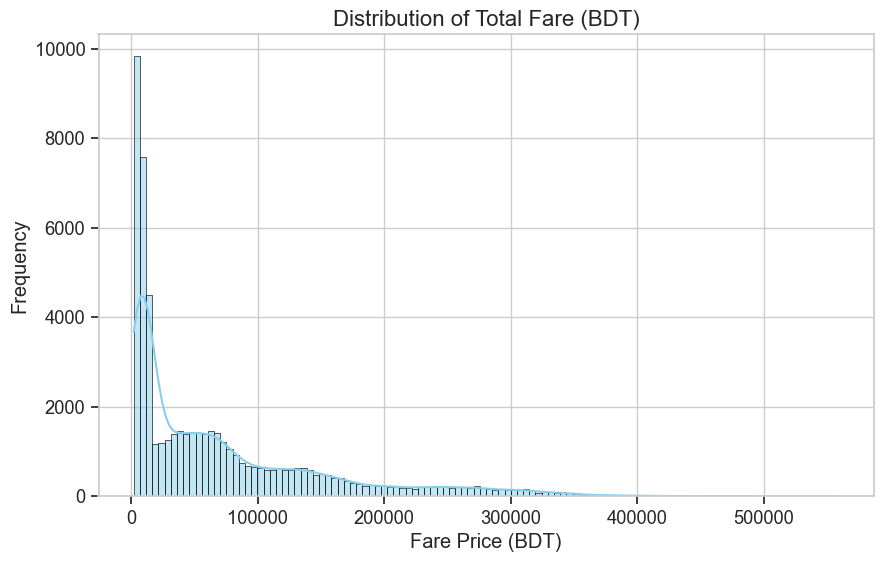

In [4]:
target_col = 'Total Fare (BDT)'  # Adjust if column name differs
if target_col in cleaned_data.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(cleaned_data[target_col], kde=True, color='skyblue')
    plt.title(f'Distribution of {target_col}', fontsize=16)
    plt.xlabel('Fare Price (BDT)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print(f"Target column '{target_col}' not found.")

### Categorical Feature Frequencies
**Visualization:** Bar charts (Countplots) for key categorical variables.

**Description:** These plots show the frequency of different categories (e.g., which airline appears most often). It helps identify imbalanced classes or dominant categories.

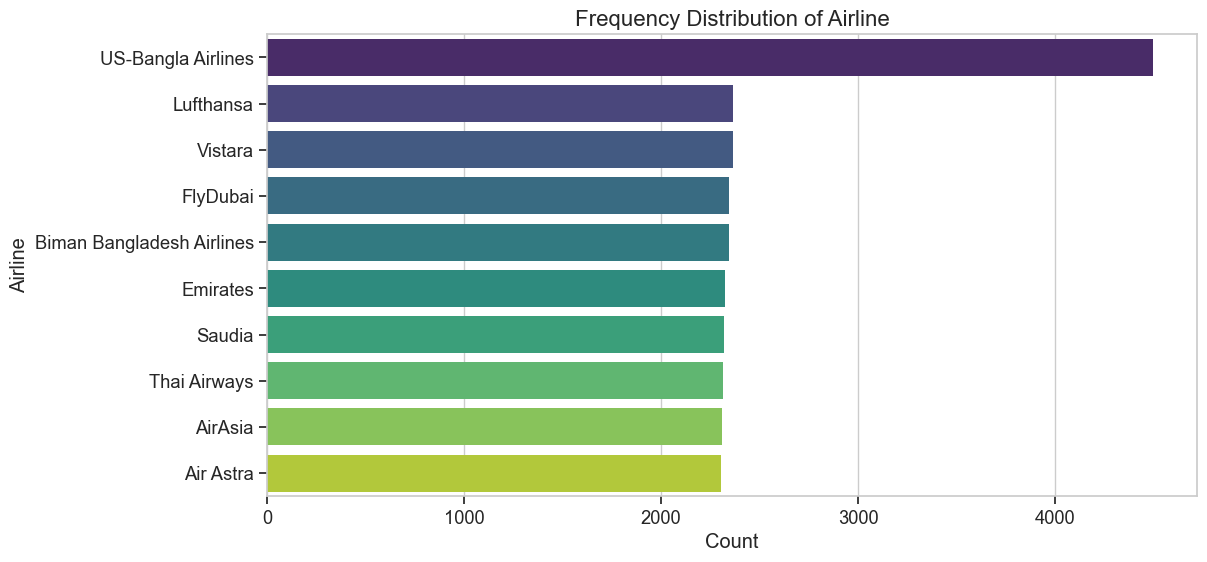

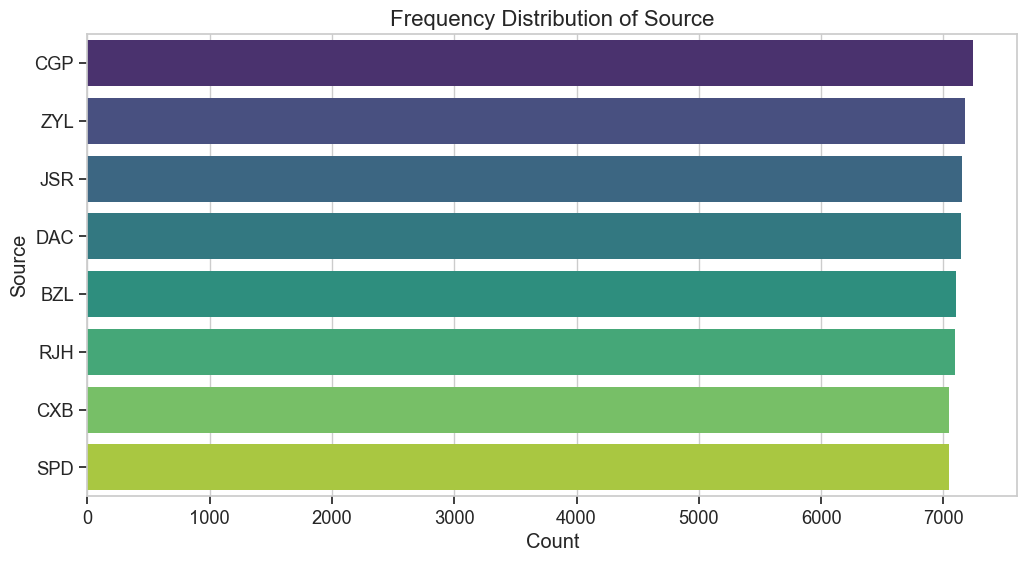

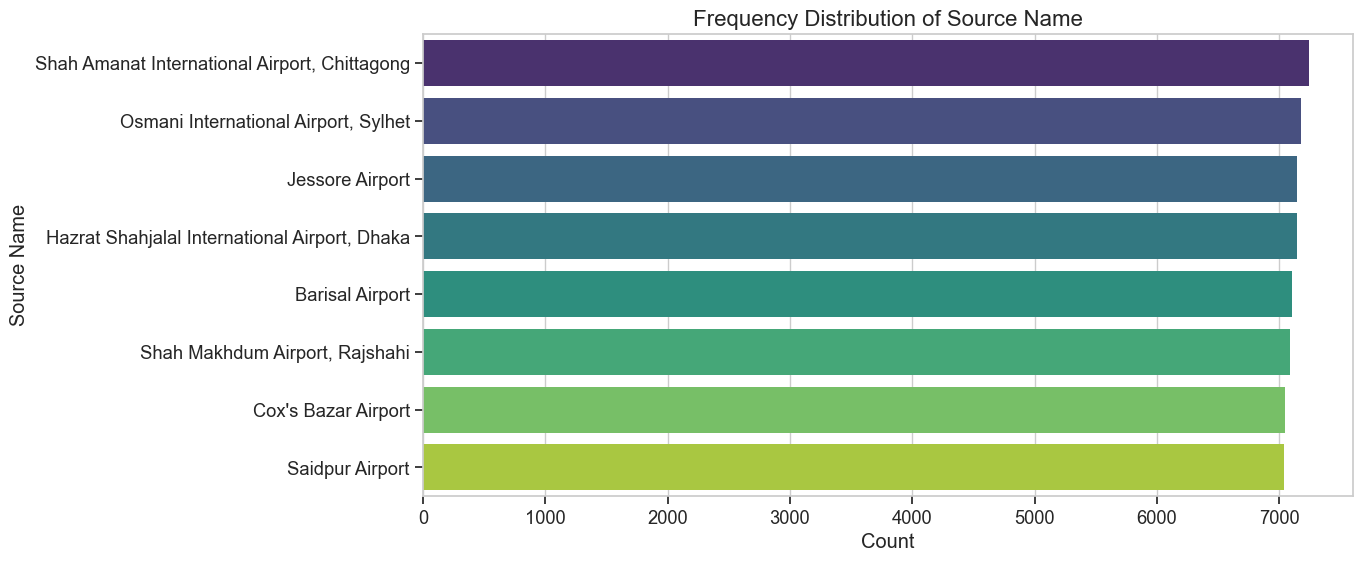

In [5]:
categorical_cols = cleaned_data.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols[:3]:  # Show first 3 categorical columns
    plt.figure(figsize=(12, 6))
    sns.countplot(data=cleaned_data, y=col, order=cleaned_data[col].value_counts().index[:10], palette='viridis')
    plt.title(f'Frequency Distribution of {col}', fontsize=16)
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

### Price vs Categorical Features
**Visualization:** Boxplots of 'Total Fare' against categorical features.

**Description:** These plots reveal how price varies across different categories (e.g., is one airline significantly more expensive?). The box shows the median and interquartile range (IQR), while points show outliers.

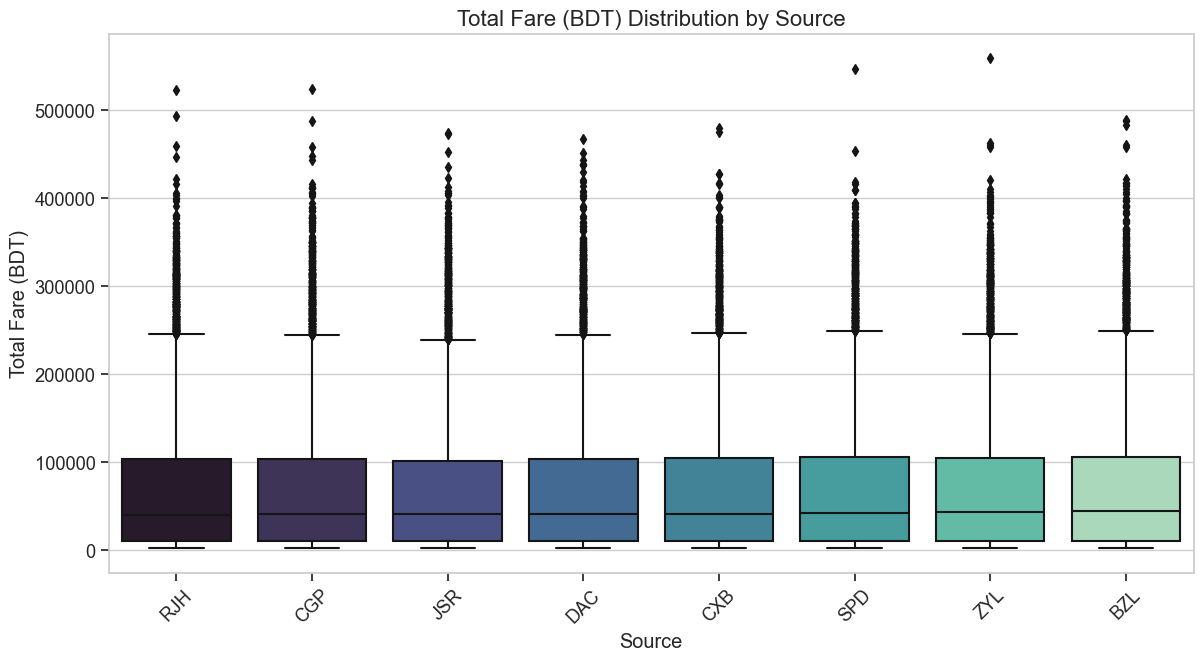

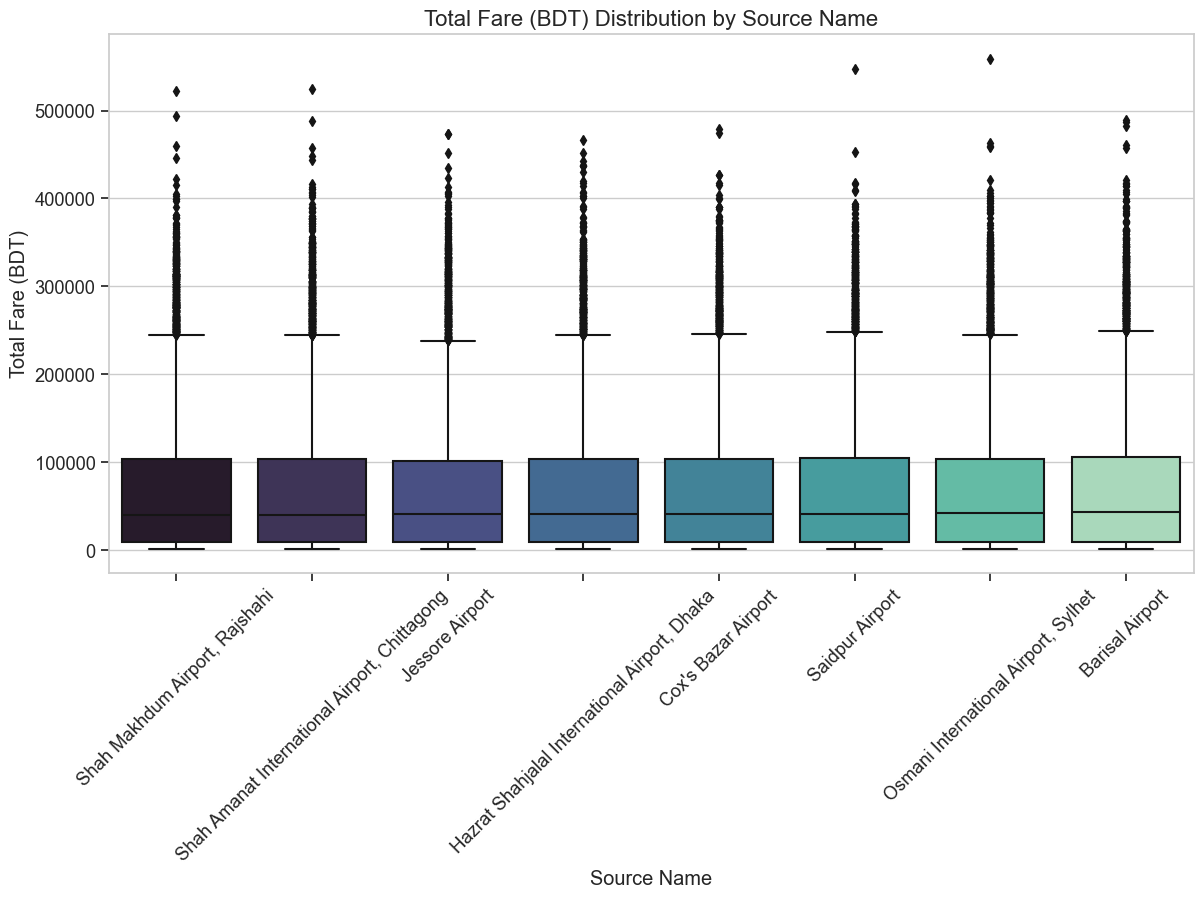

In [6]:
for col in categorical_cols[:3]:
    if len(cleaned_data[col].unique()) <= 15: # Only plot proper cats
        plt.figure(figsize=(14, 7))
        sns.boxplot(data=cleaned_data, x=col, y=target_col, order=cleaned_data.groupby(col)[target_col].median().sort_values().index, palette='mako')
        plt.xticks(rotation=45)
        plt.title(f'{target_col} Distribution by {col}', fontsize=16)
        plt.show()

### Feature Correlation Heatmap
**Visualization:** Heatmap of correlation coefficients between numerical variables.

**Description:** Shows linear relationships between variables. Values close to 1 (or -1) indicate strong correlation. This helps identify redundant features or strong predictors of price.

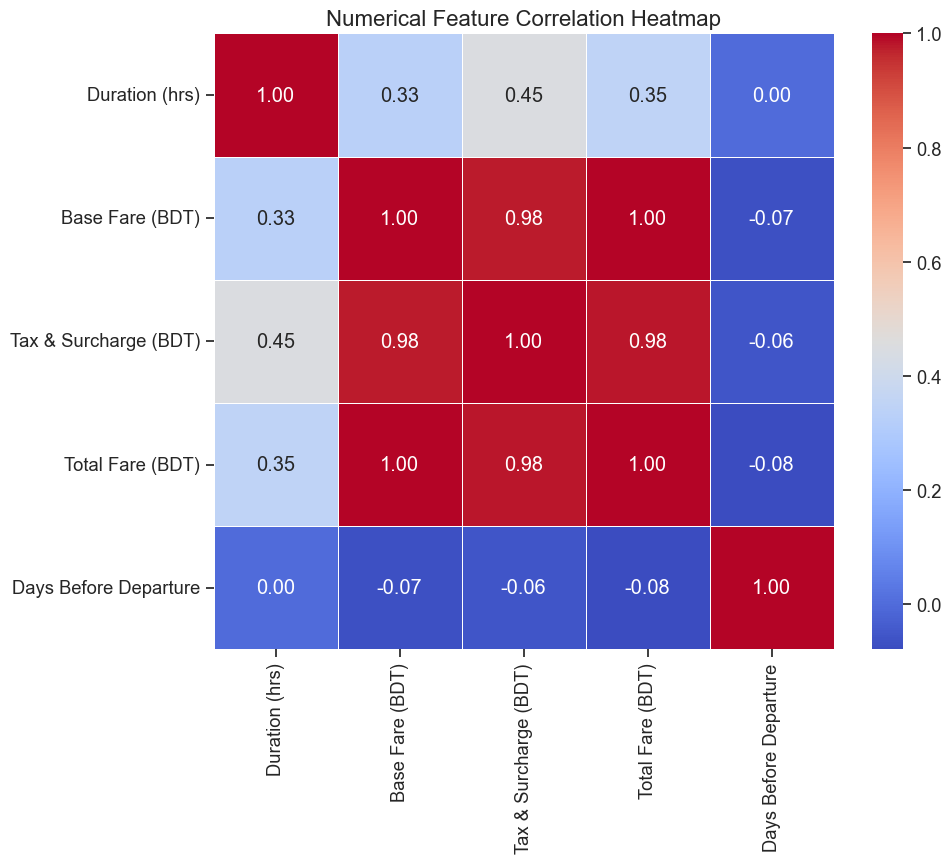

In [7]:
num_cols = cleaned_data.select_dtypes(include=['number']).columns.tolist()
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = cleaned_data[num_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Numerical Feature Correlation Heatmap', fontsize=16)
    plt.show()

## 4. Feature Engineering & Splitting
Prepare features for modeling, handle leaky columns, and split into train/test sets.

In [8]:
logger.info("STEP 4: FEATURE ENGINEERING")
feature_engineer = FeatureEngineer()

target_column = 'Total Fare (BDT)'
leaky_columns = ['Base Fare (BDT)', 'Tax & Surcharge (BDT)']

# Remove leaky columns
cols_to_drop = [c for c in leaky_columns if c in cleaned_data.columns]
data_for_modeling = cleaned_data.drop(columns=cols_to_drop)
print(f"Dropped leaky columns: {cols_to_drop}")

if target_column in data_for_modeling.columns:
    # --- TEMPORAL FEATURES ---
    logger.info("Creating temporal features...")
    data_for_modeling = feature_engineer.create_temporal_features(data_for_modeling, 'Departure Date & Time')
    data_for_modeling = data_for_modeling.rename(columns={
        'month': 'Dep_Month', 'day': 'Dep_Day', 'weekday': 'Dep_Weekday', 
        'day_of_year': 'Dep_DayOfYear', 'season': 'Dep_Season', 
        'is_weekend': 'Dep_IsWeekend', 'hour': 'Dep_Hour'
    })
    
    data_for_modeling = feature_engineer.create_temporal_features(data_for_modeling, 'Arrival Date & Time')
    data_for_modeling = data_for_modeling.rename(columns={
        'month': 'Arr_Month', 'day': 'Arr_Day', 'weekday': 'Arr_Weekday', 
        'day_of_year': 'Arr_DayOfYear', 'season': 'Arr_Season', 
        'is_weekend': 'Arr_IsWeekend', 'hour': 'Arr_Hour'
    })

    # --- ROUTE FEATURES ---
    logger.info("Creating route features...")
    data_for_modeling = feature_engineer.create_route_features(data_for_modeling)

    # Drop raw datetime columns
    data_for_modeling = feature_engineer.drop_features(data_for_modeling, ['Departure Date & Time', 'Arrival Date & Time'])

    # --- SPLIT DATA ---
    preprocessor_split = DataPreprocessor(data_for_modeling)
    X_train, X_test, y_train, y_test = preprocessor_split.split_data(target_column)
    
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")
    
    # --- CATEGORICAL ENCODING (ONE-HOT) ---
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    if cat_cols:
        logger.info(f"One-hot encoding features: {cat_cols}")
        X_train = feature_engineer.encode_categorical_features(X_train, cat_cols, method='onehot', fit=True)
        X_test = feature_engineer.encode_categorical_features(X_test, cat_cols, method='onehot', fit=False)
        
    # --- NUMERICAL SCALING ---
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    if num_cols:
        logger.info(f"Scaling numerical features: {num_cols}")
        X_train = feature_engineer.scale_numerical_features(X_train, num_cols, method='standard', fit=True)
        X_test = feature_engineer.scale_numerical_features(X_test, num_cols, method='standard', fit=False)
    
    # --- SANITIZE COLUMN NAMES (Required for XGBoost/LightGBM) ---
    import re
    def sanitize_colnames(df):
        new_cols = []
        for col in df.columns:
            new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
            new_col = re.sub(r'_+', '_', new_col)
            new_col = new_col.strip('_')
            new_cols.append(new_col)
        return new_cols
        
    X_train.columns = sanitize_colnames(X_train)
    X_test.columns = sanitize_colnames(X_test)
        
    feature_names = list(X_train.columns)
    print(f"Feature engineering complete. Total features: {len(feature_names)}")
else:
    print("Target column not found, cannot proceed to modeling.")

2026-02-12 23:46:53,648 - notebook_orchestrator - INFO - STEP 4: FEATURE ENGINEERING
2026-02-12 23:46:53,652 - src.features.feature_engineer - INFO - FeatureEngineer initialized
Dropped leaky columns: ['Base Fare (BDT)', 'Tax & Surcharge (BDT)']
2026-02-12 23:46:53,664 - notebook_orchestrator - INFO - Creating temporal features...
2026-02-12 23:46:53,671 - src.features.feature_engineer - WARNING - Column 'Departure Date & Time' is not datetime type, attempting conversion
2026-02-12 23:46:53,753 - src.features.feature_engineer - INFO - Created temporal features from 'Departure Date & Time': month, day, weekday, day_of_year, hour, season, is_weekend
2026-02-12 23:46:53,754 - src.features.feature_engineer - INFO - Created temporal features from 'Departure Date & Time': month, day, weekday, day_of_year, hour, season, is_weekend
2026-02-12 23:46:53,787 - src.features.feature_engineer - WARNING - Column 'Arrival Date & Time' is not datetime type, attempting conversion
2026-02-12 23:46:53,860

## 5. Model Training (Baseline)
Train several baseline models to establish performance benchmarks.

In [9]:
logger.info("STEP 5: BASELINE MODEL TRAINING")
trainer = ModelTrainer()
baseline_models = trainer.train_baseline_models(X_train, y_train)
print(f"Trained models: {list(baseline_models.keys())}")

2026-02-12 23:47:01,602 - notebook_orchestrator - INFO - STEP 5: BASELINE MODEL TRAINING
2026-02-12 23:47:01,604 - src.models.trainer - INFO - ModelTrainer initialized with random_state=42
2026-02-12 23:47:01,607 - src.models.trainer - INFO - Training baseline models...
2026-02-12 23:47:01,609 - src.models.trainer - INFO - Training Linear Regression...
2026-02-12 23:47:02,184 - src.models.trainer - INFO - Linear Regression - Train R²: 0.5742, RMSE: 53377.94, MAE: 40545.29
2026-02-12 23:47:02,185 - src.models.trainer - INFO - Training Ridge (alpha=1.0)...
2026-02-12 23:47:02,354 - src.models.trainer - INFO - Ridge (alpha=1.0) - Train R²: 0.5742, RMSE: 53377.32, MAE: 40548.57
2026-02-12 23:47:02,354 - src.models.trainer - INFO - Training Lasso (alpha=1.0)...
2026-02-12 23:47:43,150 - src.models.trainer - INFO - Lasso (alpha=1.0) - Train R²: 0.5742, RMSE: 53377.85, MAE: 40549.04
2026-02-12 23:47:43,151 - src.models.trainer - INFO - Training Decision Tree...


c:\Users\CourageDei\Desktop\Moodle\DE\DEM09\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.074e+13, tolerance: 3.051e+10
  model = cd_fast.enet_coordinate_descent(


2026-02-12 23:47:44,029 - src.models.trainer - INFO - Decision Tree - Train R²: 0.7200, RMSE: 43280.33, MAE: 25944.83
2026-02-12 23:47:44,030 - src.models.trainer - INFO - Training Random Forest...
2026-02-12 23:49:16,403 - src.models.trainer - INFO - Random Forest - Train R²: 0.9540, RMSE: 17540.28, MAE: 10439.65
2026-02-12 23:49:16,406 - src.models.trainer - INFO - Training XGBoost...
2026-02-12 23:49:19,490 - src.models.trainer - INFO - XGBoost - Train R²: 0.7972, RMSE: 36833.89, MAE: 23056.43
2026-02-12 23:49:19,493 - src.models.trainer - INFO - Training LightGBM...
2026-02-12 23:49:22,906 - src.models.trainer - INFO - LightGBM - Train R²: 0.7325, RMSE: 42302.82, MAE: 26084.69
2026-02-12 23:49:22,909 - src.models.trainer - INFO - Baseline model training completed
Trained models: ['Linear Regression', 'Ridge (alpha=1.0)', 'Lasso (alpha=1.0)', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']


## 6. Model Evaluation
Evaluate baseline models on the test set.

In [10]:
logger.info("STEP 6: MODEL EVALUATION")
evaluator = ModelEvaluator()

for name, model in baseline_models.items():
    metrics = trainer.evaluate_model(model, X_test, y_test, name)
    evaluator.add_model_results(name, metrics)

# Show comparison
comparison_df = evaluator.create_comparison_table()
display(comparison_df)

best_model_name, best_r2 = evaluator.get_best_model(metric='r2_score')
print(f"Best Baseline Model: {best_model_name} (R2: {best_r2:.4f})")

2026-02-12 23:49:22,967 - notebook_orchestrator - INFO - STEP 6: MODEL EVALUATION
2026-02-12 23:49:22,974 - src.evaluation.evaluator - INFO - ModelEvaluator initialized
2026-02-12 23:49:22,977 - src.models.trainer - INFO - Evaluating Linear Regression on test set...
2026-02-12 23:49:23,019 - src.models.trainer - INFO - Linear Regression Test Metrics:
2026-02-12 23:49:23,021 - src.models.trainer - INFO -   R² Score: 0.5698
2026-02-12 23:49:23,022 - src.models.trainer - INFO -   RMSE: 53551.70
2026-02-12 23:49:23,023 - src.models.trainer - INFO -   MAE: 40685.14
2026-02-12 23:49:23,027 - src.models.trainer - INFO -   MAPE: 251.83%
2026-02-12 23:49:23,030 - src.evaluation.evaluator - INFO - Added results for Linear Regression: R²=0.5698109485746254
2026-02-12 23:49:23,031 - src.models.trainer - INFO - Evaluating Ridge (alpha=1.0) on test set...
2026-02-12 23:49:23,055 - src.models.trainer - INFO - Ridge (alpha=1.0) Test Metrics:
2026-02-12 23:49:23,058 - src.models.trainer - INFO -   R² S

,r2_score,rmse,mae,mape
LightGBM,0.6779,46336.6316,27890.9021,47.2431
Random Forest,0.6663,47167.2442,28209.0619,46.1378
XGBoost,0.6570,47821.2232,29096.9395,55.6282
Decision Tree,0.6437,48737.9499,28720.1420,46.4192
Lasso (alpha=1.0),0.5699,53545.3487,40688.8804,251.7914
Ridge (alpha=1.0),0.5699,53548.3330,40689.8846,251.7791
Linear Regression,0.5698,53551.7036,40685.1415,251.8254


2026-02-12 23:49:23,790 - src.evaluation.evaluator - INFO - Best model by r2_score: LightGBM (r2_score=0.6779)
Best Baseline Model: LightGBM (R2: 0.6779)


### Actual vs Predicted Plot
**Visualization:** Scatter plot of key model predictions against actual values.

**Description:** Points on the red diagonal line represent perfect predictions. Points far from the line are errors. This visualizes model accuracy and potential bias.

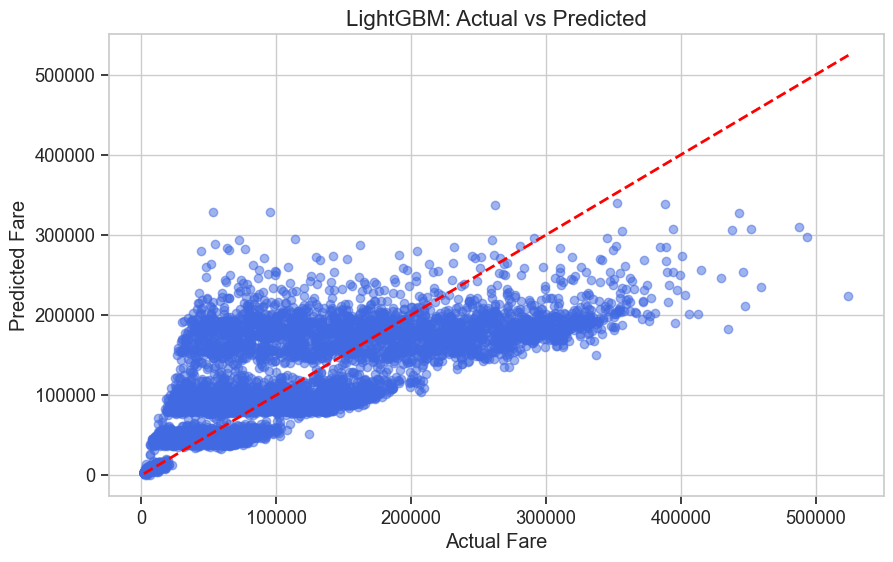

In [11]:
# Plot best model predictions
best_model = baseline_models.get(best_model_name)
if best_model:
    y_pred = best_model.predict(X_test)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Fare')
    plt.ylabel('Predicted Fare')
    plt.title(f'{best_model_name}: Actual vs Predicted', fontsize=16)
    plt.show()

### Residual Plot
**Visualization:** Scatter plot of residuals (Difference between Actual and Predicted) vs Predicted values.

**Description:** Analyzes where the model makes mistakes. We want to see a random scatter around zero. Patterns (like a curve) suggest the model is missing non-linear relationships. Increasing spread (heteroscedasticity) implies errors vary with price magnitude.

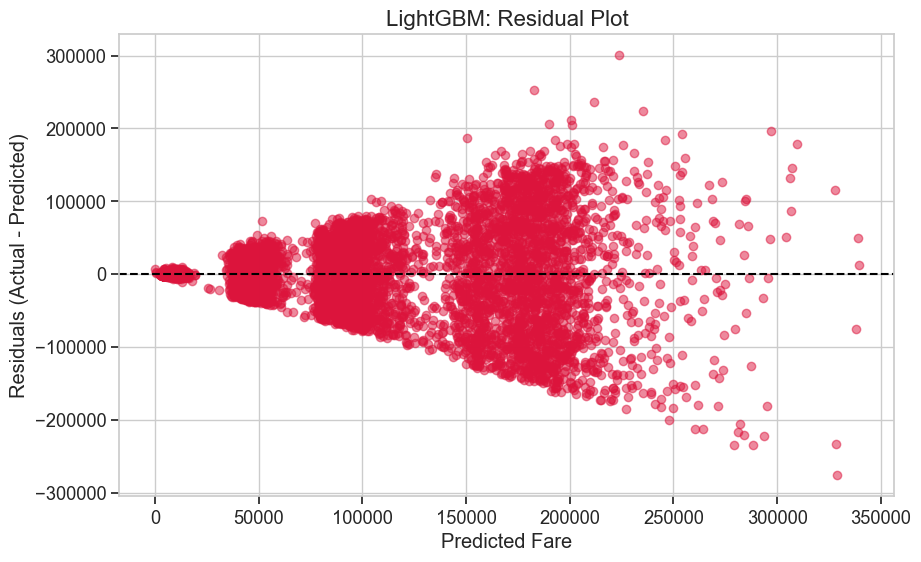

In [12]:
if best_model:
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5, color='crimson')
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('Predicted Fare')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.title(f'{best_model_name}: Residual Plot', fontsize=16)
    plt.show()

## 7. Hyperparameter Tuning
Optimize the best model using Grid Search.

In [13]:
logger.info("STEP 7: HYPERPARAMETER TUNING")
print("Tuning Random Forest... (this may take a moment)")

best_rf, best_rf_params = trainer.tune_hyperparameters(
    'random_forest',
    X_train,
    y_train,
    config.RANDOM_FOREST_PARAMS,
    search_type='grid'
)

# Evaluate tuned model
rf_metrics = trainer.evaluate_model(best_rf, X_test, y_test, 'Random Forest (Tuned)')
evaluator.add_model_results('Random Forest (Tuned)', rf_metrics)

print("Tuning complete.")
display(evaluator.create_comparison_table())

2026-02-12 23:49:25,219 - notebook_orchestrator - INFO - STEP 7: HYPERPARAMETER TUNING
Tuning Random Forest... (this may take a moment)
2026-02-12 23:49:25,222 - src.models.trainer - INFO - Tuning hyperparameters for random_forest using grid search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
2026-02-13 01:39:33,297 - src.models.trainer - INFO - Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
2026-02-13 01:39:33,302 - src.models.trainer - INFO - Best CV RMSE: 46195.59
2026-02-13 01:39:33,305 - src.models.trainer - INFO - Evaluating Random Forest (Tuned) on test set...
2026-02-13 01:39:33,510 - src.models.trainer - INFO - Random Forest (Tuned) Test Metrics:
2026-02-13 01:39:33,513 - src.models.trainer - INFO -   R² Score: 0.6795
2026-02-13 01:39:33,514 - src.models.trainer - INFO -   RMSE: 46222.59
2026-02-13 01:39:33,516 - src.models.trainer - INFO -   MAE: 27808.27
2026-02-13 01:39:33,518 - src.models.trainer -

,r2_score,rmse,mae,mape
Random Forest (Tuned),0.6795,46222.5850,27808.2675,45.6310
LightGBM,0.6779,46336.6316,27890.9021,47.2431
Random Forest,0.6663,47167.2442,28209.0619,46.1378
XGBoost,0.6570,47821.2232,29096.9395,55.6282
Decision Tree,0.6437,48737.9499,28720.1420,46.4192
Lasso (alpha=1.0),0.5699,53545.3487,40688.8804,251.7914
Ridge (alpha=1.0),0.5699,53548.3330,40689.8846,251.7791
Linear Regression,0.5698,53551.7036,40685.1415,251.8254


## 8. Feature Importance
Analyze which features drive the model's predictions.

### Feature Importance Plot
**Visualization:** Bar chart of feature importance scores.

**Description:** Shows which features had the most impact on prediction. Longer bars mean higher influence. This is crucial for explainability.

2026-02-13 01:39:33,618 - notebook_orchestrator - INFO - STEP 8: FEATURE IMPORTANCE
2026-02-13 01:39:33,625 - src.models.trainer - INFO - Extracted Feature Importance for 110 features
2026-02-13 01:39:33,629 - src.models.trainer - INFO - Top 5 features: ['Days_Before_Departure', 'Duration_hrs', 'Dep_DayOfYear', 'route_distance', 'Class_First_Class']


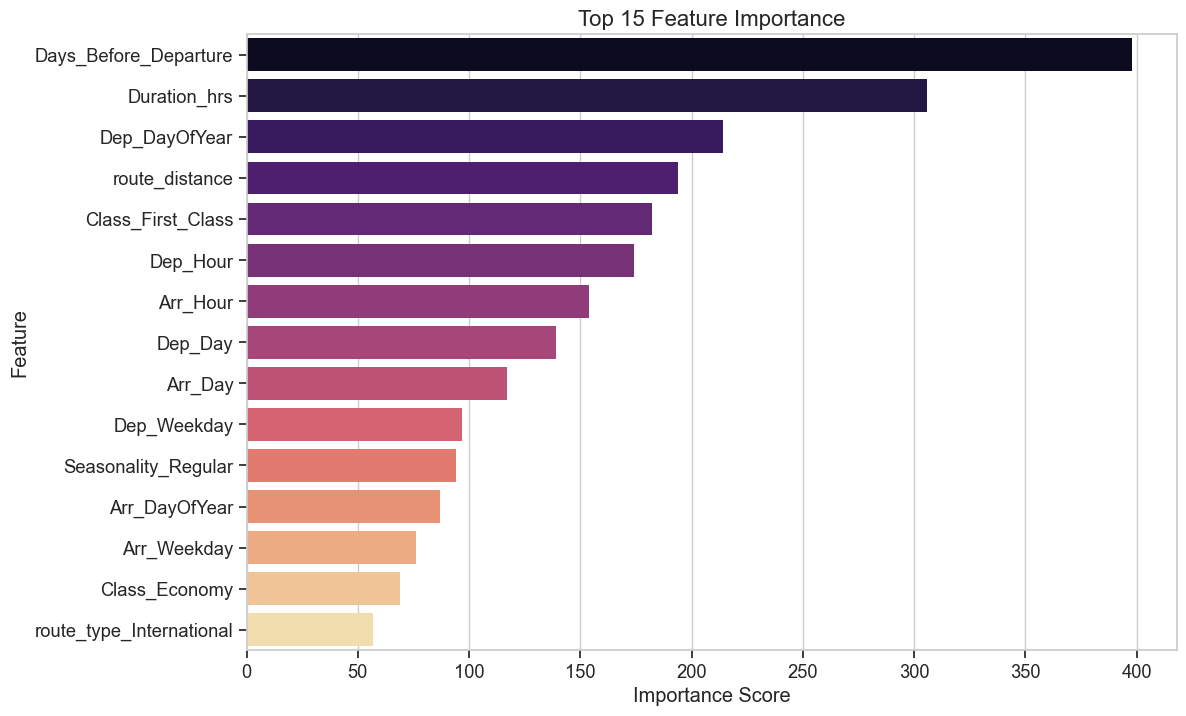

In [14]:
logger.info("STEP 8: FEATURE IMPORTANCE")
best_model = baseline_models.get(best_model_name) or best_rf
importance_df = trainer.get_feature_importance(best_model, feature_names)

if not importance_df.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='magma')
    plt.title('Top 15 Feature Importance', fontsize=16)
    plt.xlabel('Importance Score')
    plt.show()

## 9. Save Results
Save the best model and evaluation metrics.

In [15]:
logger.info("STEP 9: SAVING RESULTS")
trainer.save_model(best_model, config.BEST_MODEL_FILE)
evaluator.save_results()
print(f"Model saved to: {config.BEST_MODEL_FILE}")
print(f"Results saved to: {config.MODELS_DIR}")

2026-02-13 01:39:34,415 - notebook_orchestrator - INFO - STEP 9: SAVING RESULTS
2026-02-13 01:39:34,468 - src.utils.helpers - INFO - Object successfully saved to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\best_model.pkl
2026-02-13 01:39:34,471 - src.models.trainer - INFO - Model saved successfully to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\best_model.pkl
2026-02-13 01:39:34,482 - src.evaluation.evaluator - INFO - Saved comparison table to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\model_comparison.csv
2026-02-13 01:39:34,486 - src.utils.helpers - INFO - JSON data successfully saved to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\evaluation_results.json
2026-02-13 01:39:34,509 - src.evaluation.evaluator - INFO - Saved detailed results to C:\Users\CourageDei\Desktop\Moodle\DE\DEM09\models\evaluation_results.json
2026-02-13 01:39:34,512 - src.evaluation.evaluator - INFO - Best model by r2_score: Random Forest (Tuned) (r2_score=0.6795)
2026-02-13 01:39:34,5